In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')


In [ ]:
import pandas as pd

# Load the dataset
import pandas as pd
from google.colab import files
uploaded = files.upload()

# Display the first few rows and column information
df = pd.read_csv('osteoporosis.csv')
print(df)

Saving osteoporosis.csv to osteoporosis (1).csv
          Id  Age  Gender Hormonal Changes Family History    Race/Ethnicity  \
0     104866   69  Female           Normal            Yes             Asian   
1     101999   32  Female           Normal            Yes             Asian   
2     106567   89  Female   Postmenopausal             No         Caucasian   
3     102316   78  Female           Normal             No         Caucasian   
4     101944   38    Male   Postmenopausal            Yes  African American   
...      ...  ...     ...              ...            ...               ...   
1953  106130   19  Female           Normal            Yes  African American   
1954  106463   23  Female   Postmenopausal            Yes         Caucasian   
1955  103142   34  Female   Postmenopausal             No  African American   
1956  105187   25    Male   Postmenopausal             No  African American   
1957  108561   26  Female   Postmenopausal             No  African American   

   

In [ ]:
df.head()

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


In [ ]:
df.shape, df.columns.tolist()

((1958, 16),
 ['Id',
  'Age',
  'Gender',
  'Hormonal Changes',
  'Family History',
  'Race/Ethnicity',
  'Body Weight',
  'Calcium Intake',
  'Vitamin D Intake',
  'Physical Activity',
  'Smoking',
  'Alcohol Consumption',
  'Medical Conditions',
  'Medications',
  'Prior Fractures',
  'Osteoporosis'])

In [ ]:
df.dtypes

,0
Id,int64
Age,int64
Gender,object
Hormonal Changes,object
Family History,object
Race/Ethnicity,object
Body Weight,object
Calcium Intake,object
Vitamin D Intake,object
Physical Activity,object


In [ ]:
print(df.columns)


Index(['Id', 'Age', 'Gender', 'Hormonal Changes', 'Family History',
       'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake',
       'Physical Activity', 'Smoking', 'Alcohol Consumption',
       'Medical Conditions', 'Medications', 'Prior Fractures', 'Osteoporosis'],
      dtype='object')


In [ ]:
df.describe()


,Id,Age,Osteoporosis
count,1958.000000,1958.000000,1958.000000
mean,105515.320735,39.101124,0.500000
std,2589.407806,21.355424,0.500128
min,101008.000000,18.000000,0.000000
25%,103348.500000,21.000000,0.000000
50%,105469.000000,32.000000,0.500000
75%,107755.000000,53.000000,1.000000
max,109996.000000,90.000000,1.000000


In [ ]:
# Missing value table
missing_count=df.isnull().sum()
missing_percentage= (missing_count/len(df))*100
missing_table= pd.DataFrame({'missing_values':missing_count,
                             'missing %':missing_percentage})

print(missing_table)

                     missing_values  missing %
Id                                0   0.000000
Age                               0   0.000000
Gender                            0   0.000000
Hormonal Changes                  0   0.000000
Family History                    0   0.000000
Race/Ethnicity                    0   0.000000
Body Weight                       0   0.000000
Calcium Intake                    0   0.000000
Vitamin D Intake                  0   0.000000
Physical Activity                 0   0.000000
Smoking                           0   0.000000
Alcohol Consumption             988  50.459653
Medical Conditions              647  33.043922
Medications                     985  50.306435
Prior Fractures                   0   0.000000
Osteoporosis                      0   0.000000


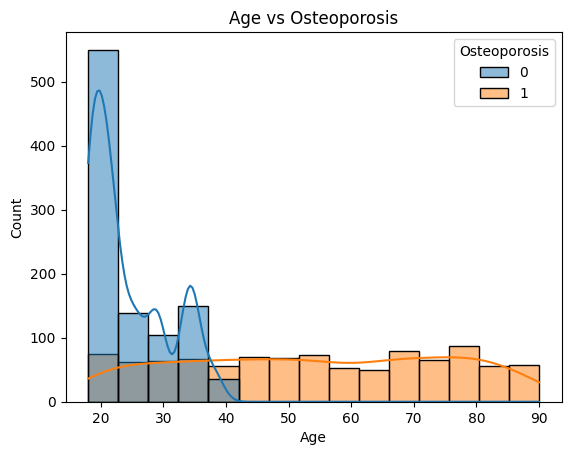

In [ ]:
plt.figure()
sns.histplot(data=df, x='Age', hue='Osteoporosis', kde=True)
plt.title('Age vs Osteoporosis')
plt.show()


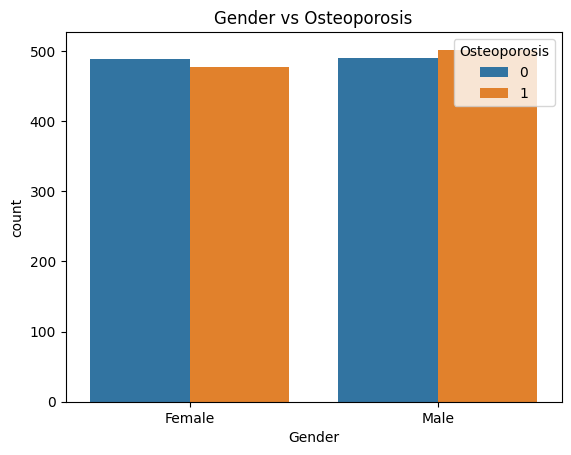

In [ ]:
plt.figure()
sns.countplot(data=df, x='Gender', hue='Osteoporosis')
plt.title('Gender vs Osteoporosis')
plt.show()


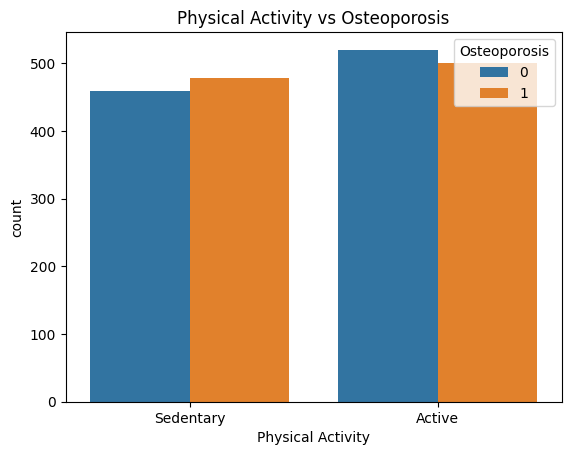

In [ ]:
plt.figure()
sns.countplot(data=df, x='Physical Activity', hue='Osteoporosis')
plt.title('Physical Activity vs Osteoporosis')
plt.show()

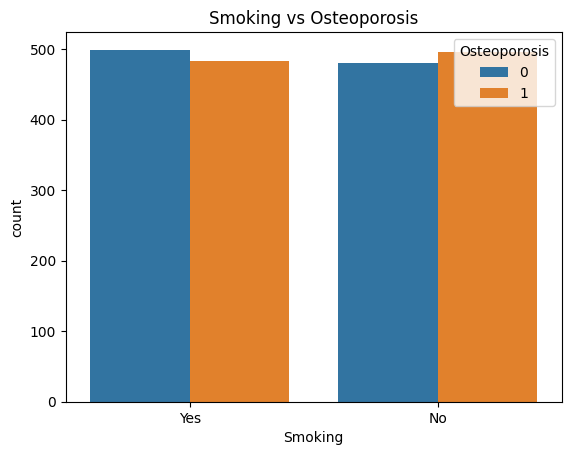

In [ ]:
plt.figure()
sns.countplot(data=df, x='Smoking', hue='Osteoporosis')
plt.title('Smoking vs Osteoporosis')
plt.show()


In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)


In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [ ]:
X = df.drop('Osteoporosis', axis=1)
y = df['Osteoporosis']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVC": SVC()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.793367,0.832370,0.734694,0.780488
1,Decision Tree,0.813776,0.818653,0.806122,0.812339
2,Random Forest,0.839286,0.958621,0.709184,0.815249
3,SVC,0.806122,0.900000,0.688776,0.780347


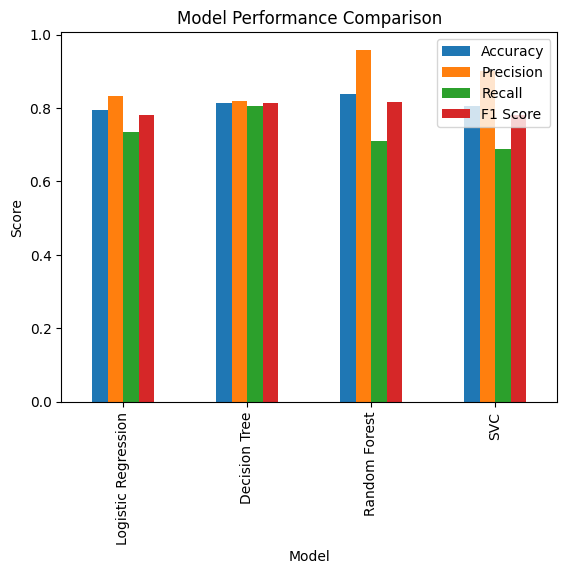

In [ ]:
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.show()


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
grid.best_params_


{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

In [ ]:
final_preds = best_model.predict(X_test)

print(classification_report(y_test, final_preds))


              precision    recall  f1-score   support

           0       0.76      0.96      0.85       196
           1       0.95      0.70      0.81       196

    accuracy                           0.83       392
   macro avg       0.85      0.83      0.83       392
weighted avg       0.85      0.83      0.83       392



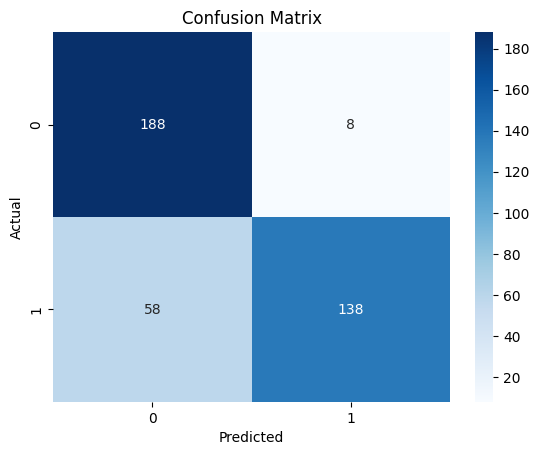

In [ ]:
cm = confusion_matrix(y_test, final_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance


,Feature,Importance
1,Age,0.701718
0,Id,0.112647
5,Race/Ethnicity,0.026388
14,Prior Fractures,0.018911
10,Smoking,0.017447
7,Calcium Intake,0.016809
4,Family History,0.016764
8,Vitamin D Intake,0.016092
12,Medical Conditions,0.016083
3,Hormonal Changes,0.015936


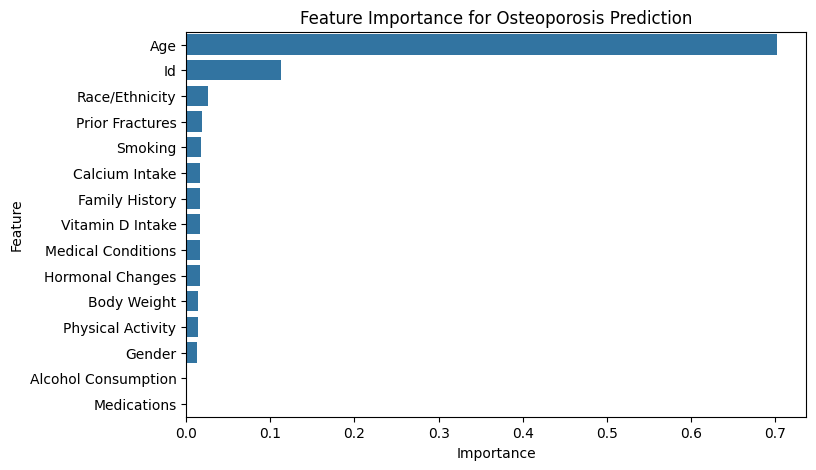

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Feature Importance for Osteoporosis Prediction')
plt.show()


In [ ]:
# Training set score
train_score = best_model.score(X_train, y_train)

# Test set score
test_score = best_model.score(X_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.9374201787994891
Test Score: 0.8316326530612245
